In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

Training a Classifier
=====================

This is it. You have seen how to define neural networks, compute loss
and make updates to the weights of the network.

Now you might be thinking,

What about data?
----------------

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a `torch.*Tensor`.

-   For images, packages such as Pillow, OpenCV are useful
-   For audio, packages such as scipy and librosa
-   For text, either raw Python or Cython based loading, or NLTK and
    SpaCy are useful

Specifically for vision, we have created a package called `torchvision`,
that has data loaders for common datasets such as ImageNet, CIFAR10,
MNIST, etc. and data transformers for images, viz.,
`torchvision.datasets` and `torch.utils.data.DataLoader`.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset. It has the classes:
'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
'ship', 'truck'. The images in CIFAR-10 are of size 3x32x32, i.e.
3-channel color images of 32x32 pixels in size.

![cifar10](https://pytorch.org/tutorials/_static/img/cifar10.png)

Training an image classifier
----------------------------

We will do the following steps in order:

1.  Load and normalize the CIFAR10 training and test datasets using
    `torchvision`
2.  Define a Convolutional Neural Network
3.  Define a loss function
4.  Train the network on the training data
5.  Test the network on the test data

### 1. Load and normalize CIFAR10

Using `torchvision`, it's extremely easy to load CIFAR10.


In [2]:
import torch
import torchvision
from torchvision.transforms import v2

The output of torchvision datasets are PILImage images of range \[0,
1\]. We transform them to Tensors of normalized range \[-1, 1\].


In [3]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:09<00:00, 17.5MB/s]


### Explanation of the Transforms and Data Loading Block

This block prepares the **CIFAR-10 dataset** for PyTorch training and testing.

#### Key Functions and Classes:

*   **`v2.Compose([...])`**: Chains multiple image transformations sequentially.
*   **`v2.ToImage()`**: Converts raw PIL images into PyTorch Image tensors.
*   **`v2.ToDtype(torch.float32, scale=True)`**: Converts pixel data to `float32` and automatically scales the value ranges from `[0, 255]` to `[0.0, 1.0]`.
*   **`v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))`**: Normalizes the 3-channel (RGB) images by subtracting `0.5` and dividing by `0.5`, shifting the values to a standard `[-1.0, 1.0]` range.
*   **`torchvision.datasets.CIFAR10(...)`**: Downloads and localizes the dataset, applying the defined transformations.
*   **`torch.utils.data.DataLoader(...)`**: Groups the dataset into batches of size 4, shuffles training data for generalization, and loads samples using parallel workers.

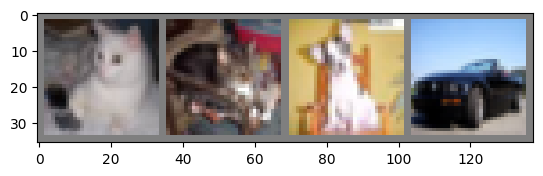

cat   cat   dog   car  


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

### Explanation of the Image Visualization Block

This block fetches a batch of random images from the training dataset and displays them along with their ground-truth labels.

#### Key Functions and Concepts:

*   **`imshow(img)`**: A custom helper function to display normalized PyTorch tensors as images.
    *   `img = img / 2 + 0.5`: Reverses the normalization transformation (which scaled pixels to `[-1, 1]`) to bring them back to the standard `[0, 1]` range.
    *   `np.transpose(npimg, (1, 2, 0))`: Rearranges the image dimensions from PyTorch's format (Channels, Height, Width) to the format expected by Matplotlib (Height, Width, Channels).
*   **`iter(trainloader)` & `next(dataiter)`**: Creates an iterator over the training data loader and retrieves the first batch of 4 images along with their corresponding label indices.
*   **`torchvision.utils.make_grid(images)`**: Organizes the batch of images into a single grid image for easier visualization.
*   **`' '.join(...)`**: Matches the target labels (integers) to their respective text class names (e.g., 'cat', 'ship') and prints them formatted in a single line.

dataiter = iter(trainloader): This creates the iterator. It does not fetch data yet. It simply sets up a pointer at the beginning of your dataset, preparing to yield data batch-by-batch.

images, labels = next(dataiter): Instead of pulling one single image, checking it, and manually incrementing (like a for i loop where i goes 1, 2, 3, 4), this single call to next() grabs one entire batch of data at the same time.

Since your batch_size is set to 4 in your dataloader:

PyTorch automatically groups 4 random images and their 4 corresponding labels behind the scenes.
next(dataiter) retrieves this whole pack of 4 at once.
So, images instantly holds a tensor of 4 images, and labels holds a tensor of 4 labels.

2. Define a Convolutional Neural Network
========================================

Copy the neural network from the Neural Networks section before and
modify it to take 3-channel images (instead of 1-channel images as it
was defined).


In [7]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

3. Define a Loss function and optimizer
=======================================

Let\'s use a Classification Cross-Entropy loss and SGD with momentum.


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

4. Train the network
====================

This is when things start to get interesting. We simply have to loop
over our data iterator, and feed the inputs to the network and optimize.


In [9]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.200
[1,  4000] loss: 1.846
[1,  6000] loss: 1.679
[1,  8000] loss: 1.584
[1, 10000] loss: 1.545
[1, 12000] loss: 1.447
[2,  2000] loss: 1.405
[2,  4000] loss: 1.365
[2,  6000] loss: 1.368
[2,  8000] loss: 1.344
[2, 10000] loss: 1.299
[2, 12000] loss: 1.271
Finished Training


### Explanation of the Training Loop Block

This block runs the training process, updating the neural network's weights so it can learn to classify the images.

#### Key Steps in the Loop:

1.  **`for epoch in range(2)`**:
    *   An **epoch** is one complete pass through the entire training dataset. Here, we loop over the dataset twice.
2.  **`for i, data in enumerate(trainloader, 0)`**:
    *   This inner loop iterates over batches of data from our loader.
    *   `data` contains a package of `[inputs, labels]` (4 images and 4 labels per batch).
3.  **`optimizer.zero_grad()`**:
    *   Clears (zeroes out) the gradients from the previous step. PyTorch accumulates gradients by default, so we must manually reset them before calculating new gradients.
4.  **`outputs = net(inputs)`**:
    *   Performs the **forward pass** by feeding the batch of images into the neural network to get its predictions.
5.  **`loss = criterion(outputs, labels)`**:
    *   Calculates the **loss** (error) by comparing the network's predictions (`outputs`) against the ground-truth targets (`labels`).
6.  **`loss.backward()`**:
    *   Performs the **backward pass** (backpropagation) to calculate the gradients of the loss with respect to all the model's parameters.
7.  **`optimizer.step()`**:
    *   Updates the network's weights based on the computed gradients using SGD (Stochastic Gradient Descent).
8.  **`running_loss += loss.item()` & `if i % 2000 == 1999`**:
    *   Tracks the cumulative loss and prints the average loss every 2000 mini-batches to monitor the model's learning progress.

Let\'s quickly save our trained model:


In [10]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

See [here](https://pytorch.org/docs/stable/notes/serialization.html) for
more details on saving PyTorch models.

5. Test the network on the test data
====================================

We have trained the network for 2 passes over the training dataset. But
we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get
familiar.


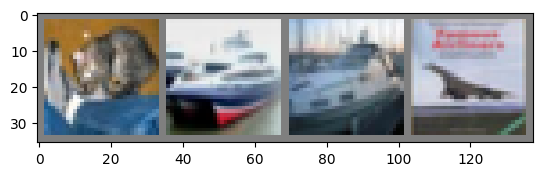

GroundTruth:  cat   ship  ship  plane


In [11]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let\'s load back in our saved model (note: saving and re-loading
the model wasn\'t necessary here, we only did it to illustrate how to do
so):


In [12]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

Okay, now let us see what the neural network thinks these examples above
are:


In [13]:
outputs = net(images)

The outputs are energies for the 10 classes. The higher the energy for a
class, the more the network thinks that the image is of the particular
class. So, let\'s get the index of the highest energy:


In [14]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   car   car   plane



The results seem pretty good.

Let us look at how the network performs on the whole dataset.


In [15]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 55 %


That looks way better than chance, which is 10% accuracy (randomly
picking a class out of 10 classes). Seems like the network learnt
something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:


In [16]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 72.4 %
Accuracy for class: car   is 69.7 %
Accuracy for class: bird  is 41.4 %
Accuracy for class: cat   is 30.9 %
Accuracy for class: deer  is 33.7 %
Accuracy for class: dog   is 45.8 %
Accuracy for class: frog  is 69.5 %
Accuracy for class: horse is 68.9 %
Accuracy for class: ship  is 58.6 %
Accuracy for class: truck is 62.6 %


Okay, so what next?

How do we run these neural networks on the GPU?

Training on GPU
===============

Just like how you transfer a Tensor onto the GPU, you transfer the
neural net onto the GPU.

Let\'s first define our device as the first visible cuda device if we
have CUDA available:


In [17]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu
